# **Introducción a QAOA mediante el problema MaxCut: de QUBO a Hamiltonianos de Ising**

# Autor: **Sebastián González Juárez**

### *Universidad Nacional Autónoma de México - Facultad de ciencias*

### Computación Cuántica II - **Proyecto Final de Laboratorio**.


*Asesores*:
- *Profesor: Salvador Elías Venegas Andraca*
- *Ayudante: Héctor Miguel Mejía Díaz*
- *Ayudante: Benjamín Sánchez Hernández*

# **1. Objetivo**

El objetivo de este proyecto es estudiar el problema de optimización combinatoria **MaxCut** mediante su formulación como un problema **QUBO** y su transformación a una formulación tipo **Ising**, para posteriormente resolverlo utilizando el algoritmo variacional cuántico **Quantum Approximate Optimization Algorithm (QAOA)**. Además, se compararán los resultados obtenidos con una **búsqueda clásica exhaustiva** y se analizará el **comportamiento del algoritmo** durante la optimización.

<div align="center">

```text
 MaxCut
    │
    ▼
 Formulación QUBO
    │
    ▼
 Hamiltoniano de Ising
    │
    ▼
 QAOA
    │
    ▼
 Solución óptima aproximada

## **1.1. Observaciones.**

La introducción teórica se encuentra detallada no en una única sección, sino que en cada sección se abarca la teoría correspondiente.

# **2. Construcción del problema MaxCut**

El problema **MaxCut** consiste en dividir los nodos de un grafo en dos conjuntos de manera que el número de aristas entre ambos grupos sea máximo. Cada posible partición puede representarse mediante **variables binarias**, donde cada nodo pertenece a uno de los dos subconjuntos.

En este proyecto se trabajará con un **grafo de seis nodos**, donde cada configuración binaria representará una posible solución del problema. Una arista contribuirá al valor del corte cuando sus dos nodos pertenezcan a conjuntos distintos.

La representación mediante variables binarias permite formular posteriormente el problema como un problema **QUBO**, facilitando su implementación mediante **algoritmos variacionales cuánticos** como **Quantum Approximate Optimization Algorithm (QAOA)**.

## **2.1. Definición del grafo**

Para este proyecto se utilizará el siguiente grafo no dirigido de **seis nodos**:

$$ E = \{(0,1), (0,2), (0,5), (1,2), (1,3), (2,4), (3,4), (3,5), (4,5)\} $$

In [ ]:
# Importamos NetworkX para crear y manipular grafos
import networkx as nx

import matplotlib.pyplot as plt

# Número de nodos del grafo
num_nodos = 6

# Aristas que conectan los nodos
aristas = [(0, 1), (0, 2), (0, 5), (1, 2), (1, 3), (2, 4), (3, 4), (3, 5),(4, 5)]

# Creamos un grafo no dirigido
grafo = nx.Graph()

# Agregamos los nodos
grafo.add_nodes_from(range(num_nodos))

# Agregamos las aristas
grafo.add_edges_from(aristas)

La estructura del grafo utilizado puede visualizarse mediante la librería **NetworkX**:

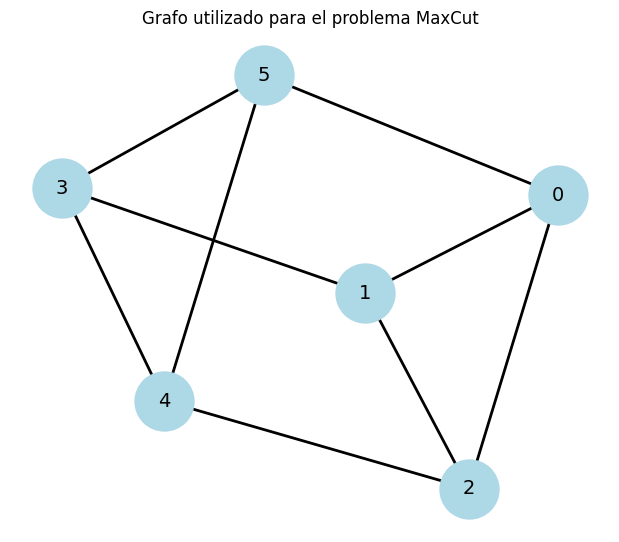

In [ ]:
# Generamos posiciones para visualizar el grafo
posiciones = nx.spring_layout(grafo, seed=42)

# Creamos la figura
plt.figure(figsize=(6, 5))

# Dibujamos el grafo
nx.draw(
    grafo,
    posiciones,
    with_labels=True,
    node_color="lightblue",
    node_size=1800,
    font_size=14,
    width=2
)

# Título de la gráfica
plt.title("Grafo utilizado para el problema MaxCut")

# Mostramos la figura
plt.show()

La conectividad entre nodos determinará qué configuraciones binarias producen un mayor número de aristas cortadas.

## **2.2. Representación binaria del problema**

Cada nodo del grafo se asociará a una variable binaria:

$$
x_i \in \{0, 1\}
$$

donde:

- $x_i = 0$ indica que el nodo pertenece al **primer conjunto**,
- $x_i = 1$ indica que pertenece al **segundo conjunto**.

Una **arista** contribuirá al valor del corte únicamente cuando los nodos conectados pertenezcan a conjuntos distintos.

Por ejemplo:

| Nodo | Valor binario |
|------|---------------|
| 0    | 0             |
| 1    | 1             |
| 2    | 0             |
| 3    | 1             |
| 4    | 1             |
| 5    | 0             |

representa una posible **partición del grafo**.

## **2.4. Valor del corte**

El valor del **MaxCut** puede calcularse contando cuántas **aristas** conectan nodos pertenecientes a **conjuntos distintos**.

In [ ]:
def valor_maxcut(cadena_bits, aristas):

    valor = 0

    # Recorremos todas las aristas del grafo
    for nodo_i, nodo_j in aristas:

        # La arista contribuye si conecta conjuntos distintos
        if cadena_bits[nodo_i] != cadena_bits[nodo_j]:
            valor += 1

    # Regresamos el número total de aristas cortadas
    return valor

Por ejemplo, consideremos la configuración:

In [ ]:
# Partición propuesta para los nodos del grafo
cadena_bits = [0, 1, 0, 1, 1, 0]

# Calculamos el valor del corte para esa partición
valor = valor_maxcut(cadena_bits, aristas)

# Mostramos los resultados
print("Cadena de bits:", cadena_bits)
print("Valor del corte:", valor)

Cadena de bits: [0, 1, 0, 1, 1, 0]
Valor del corte: 5


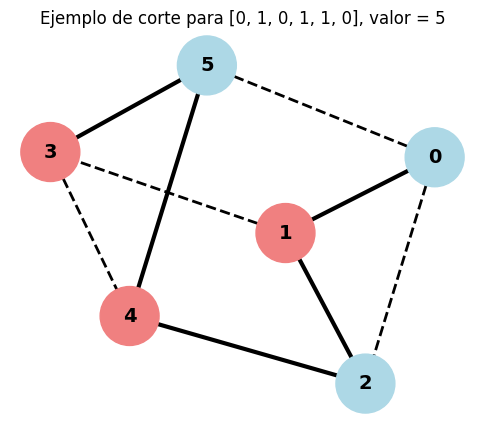

In [ ]:
# Coloreamos los nodos según la partición elegida
colores_nodos = ["lightblue" if cadena_bits[i] == 0 else "lightcoral" for i in range(num_nodos)]

# Aristas que pertenecen al corte
aristas_corte = [(nodo_i, nodo_j) for nodo_i, nodo_j in aristas if cadena_bits[nodo_i] != cadena_bits[nodo_j]]

# Aristas cuyos nodos quedan en el mismo conjunto
aristas_mismo_conjunto = [(nodo_i, nodo_j) for nodo_i, nodo_j in aristas if cadena_bits[nodo_i] == cadena_bits[nodo_j]]

# Creamos la figura
plt.figure(figsize=(6, 5))

# Dibujamos los nodos
nx.draw_networkx_nodes(grafo, posiciones, node_color=colores_nodos, node_size=1800)

# Dibujamos las etiquetas de los nodos
nx.draw_networkx_labels(grafo, posiciones, font_size=14, font_weight="bold")

# Dibujamos las aristas que no pertenecen al corte
nx.draw_networkx_edges(grafo, posiciones, edgelist=aristas_mismo_conjunto, width=2, style="dashed")

# Dibujamos las aristas que sí pertenecen al corte
nx.draw_networkx_edges(grafo, posiciones, edgelist=aristas_corte, width=3)

# Mostramos el valor del corte en el título
plt.title(f"Ejemplo de corte para {cadena_bits}, valor = {valor}")

# Ocultamos los ejes
plt.axis("off")

# Mostramos la figura
plt.show()

# **3. Formulación QUBO**

El problema **MaxCut** puede escribirse como una función cuadrática de variables binarias, obteniendo así una formulación **QUBO** (Quadratic Unconstrained Binary Optimization). El objetivo es construir una función que tome valores grandes cuando existan muchas aristas conectando nodos en **conjuntos distintos**.

## **3.1. Construcción de la función objetivo**

Para una arista $(i,j)$, el término:

$$
x_i + x_j - 2x_i x_j
$$

permite identificar si los nodos asociados pertenecen a conjuntos distintos.

Verificándolo explícitamente:

| $x_i$ | $x_j$ | $$x_i + x_j - 2x_i x_j$$ |
|:---:|:---:|:---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

Por lo tanto, el valor total del corte para el grafo completo se obtiene mediante:

$$
C(x) = \sum_{(i,j) \in E} \left( x_i + x_j - 2x_i x_j \right)
$$

Sustituyendo las aristas del grafo utilizado:

$$
\begin{aligned}
C(x) = & (x_0 + x_1 - 2x_0x_1) + (x_0 + x_2 - 2x_0x_2) \\
& + (x_0 + x_5 - 2x_0x_5) + (x_1 + x_2 - 2x_1x_2) \\
& + (x_1 + x_3 - 2x_1x_3) + (x_2 + x_4 - 2x_2x_4) \\
& + (x_3 + x_4 - 2x_3x_4) + (x_3 + x_5 - 2x_3x_5) \\
& + (x_4 + x_5 - 2x_4x_5)
\end{aligned}
$$

Agrupando términos lineales:

$$
3x_0 + 3x_1 + 3x_2 + 3x_3 + 3x_4 + 3x_5
$$

y términos cuadráticos:

$$
-2x_0x_1 - 2x_0x_2 - 2x_0x_5 - 2x_1x_2 -2x_1x_3 - 2x_2x_4 - 2x_3x_4 - 2x_3x_5 - 2x_4x_5
$$

La función objetivo queda entonces:

$$
\begin{aligned}
C(x) = & 3x_0 + 3x_1 + 3x_2 + 3x_3 + 3x_4 + 3x_5 \\
& -2x_0x_1 - 2x_0x_2 - 2x_0x_5 - 2x_1x_2 \\
& -2x_1x_3 - 2x_2x_4 - 2x_3x_4 - 2x_3x_5 - 2x_4x_5
\end{aligned}
$$

## **3.2. Construcción de la matriz QUBO**

La formulación **QUBO** puede escribirse en forma matricial como:

$$
C(x) = x^T Q x
$$

donde:

$$
x = \begin{pmatrix} x_0 \\ x_1 \\ x_2 \\ x_3 \\ x_4 \\ x_5 \end{pmatrix}
$$

Desarrollando el producto matricial:

$$
x^T Q x = \sum_{i} Q_{ii} x_i^2 + \sum_{i \neq j} Q_{ij} x_i x_j
$$

Como las variables binarias cumplen:

$$
x_i^2 = x_i
$$

los **términos diagonales** generan contribuciones lineales, mientras que los términos **fuera de la diagonal** generan las interacciones cuadráticas.

Por ejemplo, para reproducir el término:

$$
x_0 + x_1 - 2x_0 x_1
$$

la contribución correspondiente en la matriz es:

$$
Q^{(0,1)} = \begin{pmatrix}
1 & -1 & 0 & 0 & 0 & 0 \\
-1 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0
\end{pmatrix}
$$

ya que:

$$
x^T Q^{(0,1)} x = x_0^2 + x_1^2 - x_0 x_1 - x_1 x_0
$$

y usando $x_i^2 = x_i$ se obtiene:

$$
x_0 + x_1 - 2x_0 x_1
$$

Aplicando el mismo procedimiento para **todas las aristas** se obtiene:

$$
Q = \begin{pmatrix}
3 & -1 & -1 & 0 & 0 & -1 \\
-1 & 3 & -1 & -1 & 0 & 0 \\
-1 & -1 & 3 & 0 & -1 & 0 \\
0 & -1 & 0 & 3 & -1 & -1 \\
0 & 0 & -1 & -1 & 3 & -1 \\
-1 & 0 & 0 & -1 & -1 & 3
\end{pmatrix}
$$

## **3.3. Implementación computacional**

Una vez obtenida la **matriz QUBO** de forma analítica, podemos construirla computacionalmente utilizando **Python**. Para ello, inicializamos una **matriz de ceros** de tamaño **6×6** y posteriormente recorremos **todas las aristas del grafo**.

Cada **arista (i,j)** aporta:

- una contribución **+1** a los **términos diagonales** asociados a los nodos i y j,
- y una contribución **−1** a las **interacciones** entre dichos nodos.

La **implementación** queda:

In [ ]:
import numpy as np

# Inicializamos la matriz QUBO con ceros
matriz_qubo = np.zeros((num_nodos, num_nodos))

# Recorremos las aristas del grafo
for nodo_i, nodo_j in aristas:

    # Agregamos los términos lineales
    matriz_qubo[nodo_i, nodo_i] += 1
    matriz_qubo[nodo_j, nodo_j] += 1

    # Agregamos los términos cuadráticos
    matriz_qubo[nodo_i, nodo_j] += -1
    matriz_qubo[nodo_j, nodo_i] += -1

# Mostramos la matriz QUBO
print("Matriz QUBO:")
print(matriz_qubo)

Matriz QUBO:
[[ 3. -1. -1.  0.  0. -1.]
 [-1.  3. -1. -1.  0.  0.]
 [-1. -1.  3.  0. -1.  0.]
 [ 0. -1.  0.  3. -1. -1.]
 [ 0.  0. -1. -1.  3. -1.]
 [-1.  0.  0. -1. -1.  3.]]


Ahora verificaremos que esta **matriz** reproduce correctamente el valor del problema **MaxCut**.

Tomemos la configuración binaria:

**x = (0, 1, 0, 1, 1, 0)**

El valor del corte puede calcularse directamente usando:

In [ ]:
# Bitstring de ejemplo
cadena_bits = [0, 1, 0, 1, 1, 0]

# Calculamos el valor del corte
valor = valor_maxcut(cadena_bits, aristas)

# Mostramos el resultado
print("Valor del corte:", valor)

Valor del corte: 5


Ahora a calcularse mediante la **forma matricial**:

$$
C(x) = x^T Q x
$$

In [ ]:
# Calcula el valor de la función QUBO: xᵀQx
def valor_qubo(cadena_bits, matriz_qubo):

    # Convertimos la cadena de bits en un arreglo de NumPy
    cadena_bits = np.array(cadena_bits)

    # Calculamos el producto matricial xᵀQx
    return cadena_bits.T @ matriz_qubo @ cadena_bits


# Mostramos el valor obtenido con la formulación QUBO
print(
    "Valor usando xᵀQx:",
    valor_qubo(cadena_bits, matriz_qubo)
)

Valor usando xᵀQx: 5.0


# **4. Transformación QUBO-Ising**

En la **sección anterior** formulé el problema **MaxCut** como un problema **QUBO** utilizando variables binarias:

$$ x_i \in \{0,1\} $$

Sin embargo, para construir posteriormente un **Hamiltoniano cuántico**, necesito expresar la función objetivo en términos de **variables de spin**:

$$ z_i \in \{-1, +1\} $$

Por ello, en esta sección realizaré la **conversión de la formulación QUBO al modelo de Ising**.

## **4.1. De variables binarias a variables de spin**

En la **formulación QUBO** se utilizan **variables binarias**:

$$ x_i \in \{0,1\} $$

mientras que en el **modelo de Ising** se emplean **variables de spin**:

$$ z_i \in \{-1, +1\} $$

Por ello, es necesario establecer una **correspondencia** entre ambas representaciones. La relación utilizada será:

$$ x_i = \frac{1 - z_i}{2} $$

Esta transformación cumple que:

$$ z_i = +1 \implies x_i = 0 $$

y

$$ z_i = -1 \implies x_i = 1 $$

Por lo tanto, cada asignación binaria posee una **representación equivalente** en términos de variables de spin.

Como ejemplo, para la partición utilizada anteriormente:

$$ x = [0, 1, 0, 1, 1, 0] $$

la **transformación inversa**:

$$ z_i = 1 - 2x_i $$

produce:

$$ z = [1, -1, 1, -1, -1, 1] $$

En código esta conversión se realizá:

In [ ]:
# Conversión de variables binarias a variables de spin
variables_spin = [1 - 2 * bit for bit in cadena_bits]

# Mostramos los resultados
print("Variables binarias =", cadena_bits)
print("Variables de spin =", variables_spin)

Variables binarias = [0, 1, 0, 1, 1, 0]
Variables de spin = [1, -1, 1, -1, -1, 1]


## **4.2. Sustitución de la función QUBO en variables de spin**

Una vez establecida la **relación entre las variables binarias** $x_i$ y las **variables de spin** $z_i$, el siguiente paso consiste en **reescribir la función objetivo de MaxCut** en términos de $z_i$.

Partiendo de la **formulación utilizada anteriormente**:

$$ C(x) = \sum_{(i,j) \in E} \left( x_i + x_j - 2x_i x_j \right) $$

se sustituye:

$$ x_i = \frac{1 - z_i}{2}, \quad x_j = \frac{1 - z_j}{2} $$

Entonces:

$$ C(z) = \sum_{(i,j) \in E} \left[ \frac{1 - z_i}{2} + \frac{1 - z_j}{2} - 2 \left( \frac{1 - z_i}{2} \right) \left( \frac{1 - z_j}{2} \right) \right] = \sum_{(i,j) \in E} \left[ \frac{2 - z_i - z_j}{2} - \frac{(1 - z_i)(1 - z_j)}{2} \right] = \sum_{(i,j) \in E} \left[ \frac{2 - z_i - z_j}{2} - \frac{1 - z_i - z_j + z_i z_j}{2} \right] = \sum_{(i,j) \in E} \frac{1 - z_i z_j}{2} $$

Esta expresión es la **formulación de MaxCut en variables de spin**. Puede observarse que una **arista aporta energía nula** cuando los spins son iguales ($z_i = z_j$) y **aporta una unidad** cuando los spins son opuestos ($z_i \neq z_j$), reproduciendo exactamente el **comportamiento de la función objetivo original**.

## **4.3. Construcción del Hamiltoniano de Ising**

La **expresión obtenida en la sección anterior** ya tiene la forma característica de un **modelo de Ising**:

$$ C(z) = \sum_{(i,j) \in E} \frac{1 - z_i z_j}{2} $$

Para llevar esta formulación al **contexto cuántico**, las **variables de spin** $z_i$ se reemplazan por **operadores de Pauli-Z** actuando sobre el qubit correspondiente. Es decir:

$$ z_i \rightarrow Z_i $$

Con esta sustitución, la **función objetivo** se transforma en el **Hamiltoniano de costo**:

$$ H_C = \sum_{(i,j) \in E} \frac{1 - Z_i Z_j}{2} $$

Cada **término del Hamiltoniano** involucra únicamente **dos qubits** conectados por una arista del grafo. Además, cuando dos qubits se encuentran en **estados opuestos**, el término asociado contribuye favorablemente al valor del corte, mientras que **estados iguales** producen una contribución menor. De esta manera, la estructura del Hamiltoniano conserva la **información del problema MaxCut original**.

Para el **grafo utilizado en este proyecto**, el Hamiltoniano queda dado por:

$$
\begin{aligned}
H_C =& \frac{1}{2}(I - Z_0 Z_1) + \frac{1}{2}(I - Z_0 Z_2) + \frac{1}{2}(I - Z_0 Z_5) \\
&+ \frac{1}{2}(I - Z_1 Z_2) + \frac{1}{2}(I - Z_1 Z_3) + \frac{1}{2}(I - Z_2 Z_4) \\
&+ \frac{1}{2}(I - Z_3 Z_4) + \frac{1}{2}(I - Z_3 Z_5) + \frac{1}{2}(I - Z_4 Z_5)
\end{aligned}
$$

Este **Hamiltoniano** será el utilizado posteriormente por **QAOA** para **codificar la función objetivo** del problema **MaxCut**.

## **4.4. Construcción computacional del Hamiltoniano**

Una vez obtenida la **expresión analítica del Hamiltoniano de costo**, el siguiente paso consiste en **construirlo de forma computacional**. Para ello, cada término $Z_i Z_j$ asociado a una **arista del grafo** se representará mediante **cadenas de operadores de Pauli** actuando sobre los qubits correspondientes.

Por ejemplo, para un **sistema de seis qubits**, el término:

$$ Z_0 Z_1 $$

puede escribirse como:

$$ ZZIIII $$

mientras que:

$$ Z_1 Z_3 $$

se representa como:

$$ IZIZII $$

Siguiendo este **procedimiento** para **todas las aristas del grafo** es posible **construir automáticamente** el Hamiltoniano completo, evitando escribir cada término de manera manual.

La siguiente celda genera los **operadores de Pauli** correspondientes a cada arista del problema **MaxCut** (Recordemos quien es Edges).

In [ ]:
!pip install qiskit -q

In [ ]:
!pip install qiskit-aer -q

Importamos para representar operadores de Paul:

In [ ]:
from qiskit.quantum_info import SparsePauliOp

In [ ]:
# Lista donde se almacenarán los términos del Hamiltoniano
lista_pauli = []

# Recorremos todas las aristas del grafo
for nodo_i, nodo_j in aristas:

    # Inicializamos una cadena de identidades
    etiqueta = ["I"] * num_nodos

    # Colocamos operadores Z en los qubits conectados por la arista
    etiqueta[nodo_i] = "Z"
    etiqueta[nodo_j] = "Z"

    # Convertimos la lista en una cadena de Pauli
    cadena_pauli = "".join(etiqueta)

    # Agregamos el término ZZ con coeficiente -1/2
    lista_pauli.append((cadena_pauli, -0.5))

# Construimos el Hamiltoniano de costo
hamiltoniano_costo = SparsePauliOp.from_list(lista_pauli)

# Mostramos el Hamiltoniano resultante
print(hamiltoniano_costo)

SparsePauliOp(['ZZIIII', 'ZIZIII', 'ZIIIIZ', 'IZZIII', 'IZIZII', 'IIZIZI', 'IIIZZI', 'IIIZIZ', 'IIIIZZ'],
              coeffs=[-0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j,
 -0.5+0.j, -0.5+0.j])


# **5. Quantum Approximate Optimization Algorithm (QAOA)**

Hasta este punto, el problema **MaxCut** ha sido reformulado como un **Hamiltoniano de costo de Ising**. El **objetivo de QAOA** es utilizar dicho Hamiltoniano para **preparar estados cuánticos** que tengan alta probabilidad de representar **soluciones cercanas al óptimo**.

**QAOA** combina una **evolución asociada al Hamiltoniano de costo**, que incorpora la **información del problema**, con una **evolución asociada a un Hamiltoniano mezclador**, cuya función es **explorar diferentes configuraciones del espacio de búsqueda**. Ambas evoluciones se aplican de manera **alternada** mediante **parámetros variacionales** que posteriormente son **optimizados por un algoritmo clásico**.

## **5.1. Idea general de QAOA**

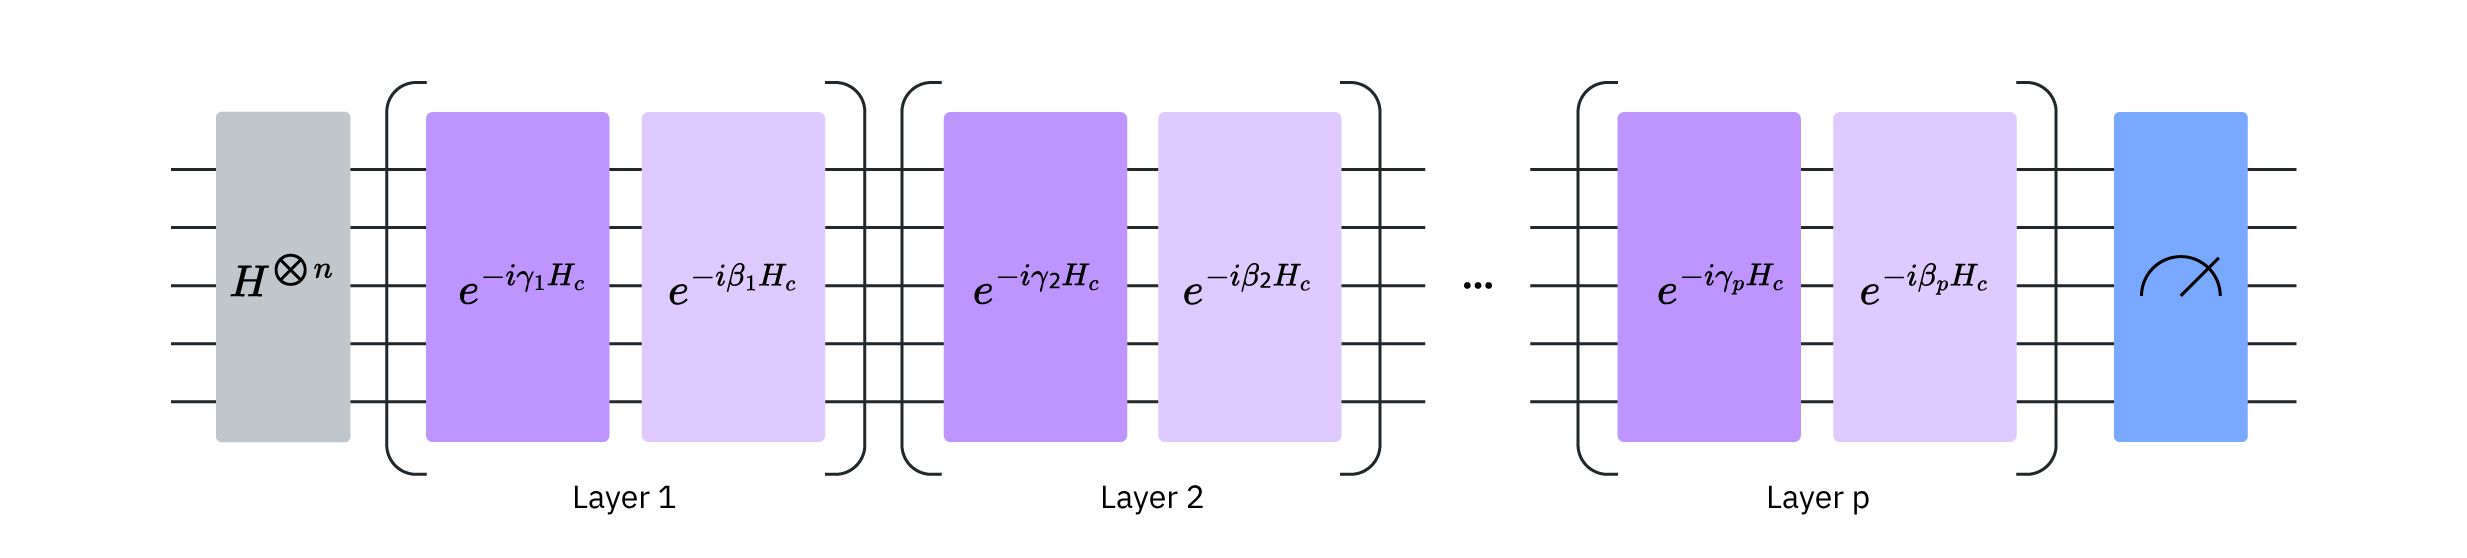

El **algoritmo** comienza preparando un **estado inicial uniforme** sobre todas las posibles configuraciones de los qubits:

$$ |+\rangle^{\otimes n} = \frac{1}{\sqrt{2^n}} \sum_{z \in \{0,1\}^n} |z\rangle $$

Este **estado** se obtiene aplicando una **compuerta Hadamard** a cada qubit inicializado en $|0\rangle$.

Posteriormente, **QAOA** aplica de forma alternada dos **operadores unitarios**:

$$ U_C(\gamma) = e^{-i\gamma H_C} $$

denominado **operador de costo**, y

$$ U_M(\beta) = e^{-i\beta H_M} $$

denominado **operador mezclador**.

El **Hamiltoniano de costo** $H_C$ corresponde al problema **MaxCut** construido en la sección anterior, mientras que el **Hamiltoniano mezclador** se define como:

$$ H_M = \sum_{i=0}^{n-1} X_i $$

donde $X_i$ representa el **operador de Pauli-X** actuando sobre el qubit $i$.

Una **capa de QAOA** consiste en aplicar primero $U_C(\gamma)$ y después $U_M(\beta)$. Si se utilizan **$p$ capas**, el **estado final** queda dado por:

$$ |\psi(\boldsymbol{\gamma}, \boldsymbol{\beta})\rangle = U_M(\beta_p) U_C(\gamma_p) \cdots U_M(\beta_1) U_C(\gamma_1) |+\rangle^{\otimes n} $$

Los **parámetros**:

$$ \boldsymbol{\gamma} = (\gamma_1, \dots, \gamma_p) $$

y

$$ \boldsymbol{\beta} = (\beta_1, \dots, \beta_p) $$

se ajustan mediante un **optimizador clásico** para **maximizar el valor esperado** de la función objetivo.

## **5.2. Construcción del estado inicial uniforme**

**QAOA** comienza preparando un **estado uniforme** sobre todas las configuraciones posibles de los qubits. Para un sistema de **$n$ qubits**, este estado se escribe como:

$$ |+\rangle^{\otimes n} = \frac{1}{\sqrt{2^n}} \sum_{z \in \{0,1\}^n} |z\rangle $$

En este proyecto se utilizan **$n = 6$ qubits**, uno por cada **nodo del grafo**. El **estado uniforme** se obtiene aplicando una **compuerta Hadamard** a cada qubit inicialmente preparado en el estado $|0\rangle$.

La siguiente celda construye este **estado inicial**.

In [ ]:
!pip install pylatexenc -q

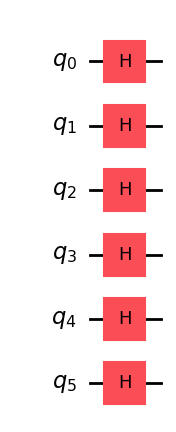

In [ ]:
from qiskit import QuantumCircuit

# Circuito con un qubit por cada nodo del grafo
circuito = QuantumCircuit(num_nodos)

# Preparamos el estado uniforme |+⟩⊗n
circuito.h(range(num_nodos))

# Visualizamos el circuito
circuito.draw("mpl")

Después de aplicar las **compuertas Hadamard**, el **estado del sistema** queda dado por:

$$ |+\rangle^{\otimes 6} = \frac{1}{\sqrt{64}} \sum_{z=0}^{63} |z\rangle = \frac{1}{8} \sum_{z=0}^{63} |z\rangle $$

por lo que **todas las configuraciones binarias posibles** poseen inicialmente la **misma amplitud**. A partir de este **estado**, las **evoluciones asociadas al Hamiltoniano de costo** y al **Hamiltoniano mezclador** modificarán dichas amplitudes para **concentrar probabilidad** en las **soluciones de mayor calidad**.

## **5.3. Operador de costo $U_C(\gamma)$**

Una vez preparado el **estado inicial uniforme**, **QAOA** aplica el **operador de costo**:

$$ U_C(\gamma) = e^{-i\gamma H_C} $$

donde $H_C$ es el **Hamiltoniano** construido a partir del problema **MaxCut** y $\gamma$ es un **parámetro variacional**.

Este **operador** modifica las **fases de los estados cuánticos** de acuerdo con la **función objetivo** del problema. Como consecuencia, las **configuraciones asociadas a cortes de mayor valor** adquieren **fases distintas** a las de configuraciones menos favorables, permitiendo que posteriormente la **interferencia cuántica** favorezca las **soluciones de mejor calidad**.

Para el **problema considerado en este proyecto**, el **Hamiltoniano de costo** está compuesto por términos de la forma $Z_i Z_j$, por lo que el **operador de costo** puede escribirse como:

$$ U_C(\gamma) = e^{-i\gamma H_C} = \prod_{(i,j) \in E} e^{i\frac{\gamma}{2} Z_i Z_j} $$

ignorando el **término constante** del Hamiltoniano, ya que éste únicamente introduce una **fase global** que no afecta las **probabilidades de medición**.

En un **circuito cuántico**, cada término $e^{i\theta Z_i Z_j}$ puede implementarse mediante **dos compuertas CNOT** y una **rotación alrededor del eje Z**. Por ello, para cada **arista del grafo** se construye un bloque que introduce la **interacción** correspondiente entre los qubits conectados.

La siguiente celda implementa el **operador de costo** para una **capa de QAOA**.

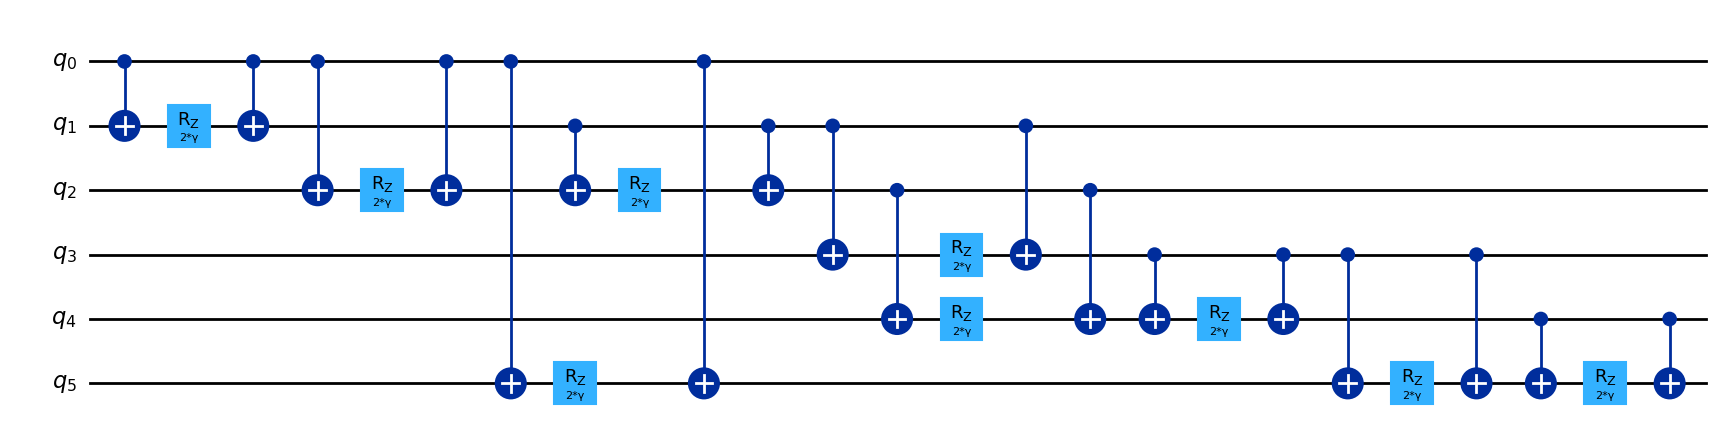

In [ ]:
# Importamos Parameter para definir parámetros simbólicos
from qiskit.circuit import Parameter

# Parámetro variacional asociado al Hamiltoniano de costo
gamma = Parameter("γ")

# Circuito que implementa el operador de costo
circuito_costo = QuantumCircuit(num_nodos)

# Recorremos las aristas del grafo
for nodo_i, nodo_j in aristas:

    # Entrelazamiento auxiliar
    circuito_costo.cx(nodo_i, nodo_j)

    # Rotación que implementa la interacción ZZ
    circuito_costo.rz(2 * gamma, nodo_j)

    # Deshacemos el entrelazamiento auxiliar
    circuito_costo.cx(nodo_i, nodo_j)

# Visualizamos el circuito
circuito_costo.draw("mpl")

## **5.4. Operador mezclador $U_M(\beta)$**

El segundo operador denominado **operador mezclador**, definido como:

$$ U_M(\beta) = e^{-i\beta H_M} $$

donde $\beta$ es un **parámetro variacional** y

$$ H_M = \sum_{i=0}^{n-1} X_i $$

es el **Hamiltoniano mezclador** construido a partir de **operadores de Pauli-X**.

La **función** de este operador es permitir la **exploración del espacio de soluciones**. Mientras que el **operador de costo** incorpora la **información del problema MaxCut**, el **operador mezclador** introduce **transiciones entre estados de la base computacional**, evitando que la **evolución** quede atrapada en una única configuración.

Debido a que todos los **operadores** $X_i$ actúan sobre **qubits distintos**, el **operador mezclador** puede escribirse como:

$$ U_M(\beta) = \prod_{i=0}^{n-1} e^{-i\beta X_i} $$

Cada **término** de esta expresión corresponde a una **rotación alrededor del eje X**, por lo que su **implementación en un circuito cuántico** resulta particularmente sencilla mediante **compuertas $R_X$**.

La siguiente celda construye el **operador mezclador** para una **capa de QAOA**.

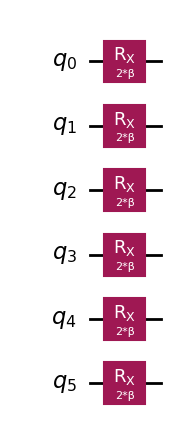

In [ ]:
# Parámetro variacional asociado al operador mezclador
beta = Parameter("")
β
# Circuito que implementa el operador mezclador
circuito_mezclador = QuantumCircuit(num_nodos)

# Aplicamos una rotación RX a cada qubit
for qubit in range(num_nodos):
    circuito_mezclador.rx(2 * beta, qubit)

# Visualizamos el circuito
circuito_mezclador.draw("mpl")

## **5.5. Construcción de una capa QAOA**

Una **capa de QAOA** se obtiene aplicando de manera secuencial el **operador de costo** $U_C(\gamma)$ y el **operador mezclador** $U_M(\beta)$ sobre el **estado inicial uniforme**. Para una **profundidad $p=1$**, el **estado resultante** puede escribirse como:

$$ |\psi(\gamma, \beta)\rangle = U_M(\beta) U_C(\gamma) |+\rangle^{\otimes n} $$

Aunque una **sola capa** no garantiza encontrar la **solución óptima**, suele ser suficiente para **capturar parte de la estructura** del problema y **aproximar soluciones de buena calidad**. A medida que **aumenta el número de capas $p$**, el circuito dispone de **mayor capacidad** para representar **estados cercanos al óptimo**.

La siguiente celda construye una **capa completa de QAOA** para el problema **MaxCut** considerado en este proyecto.

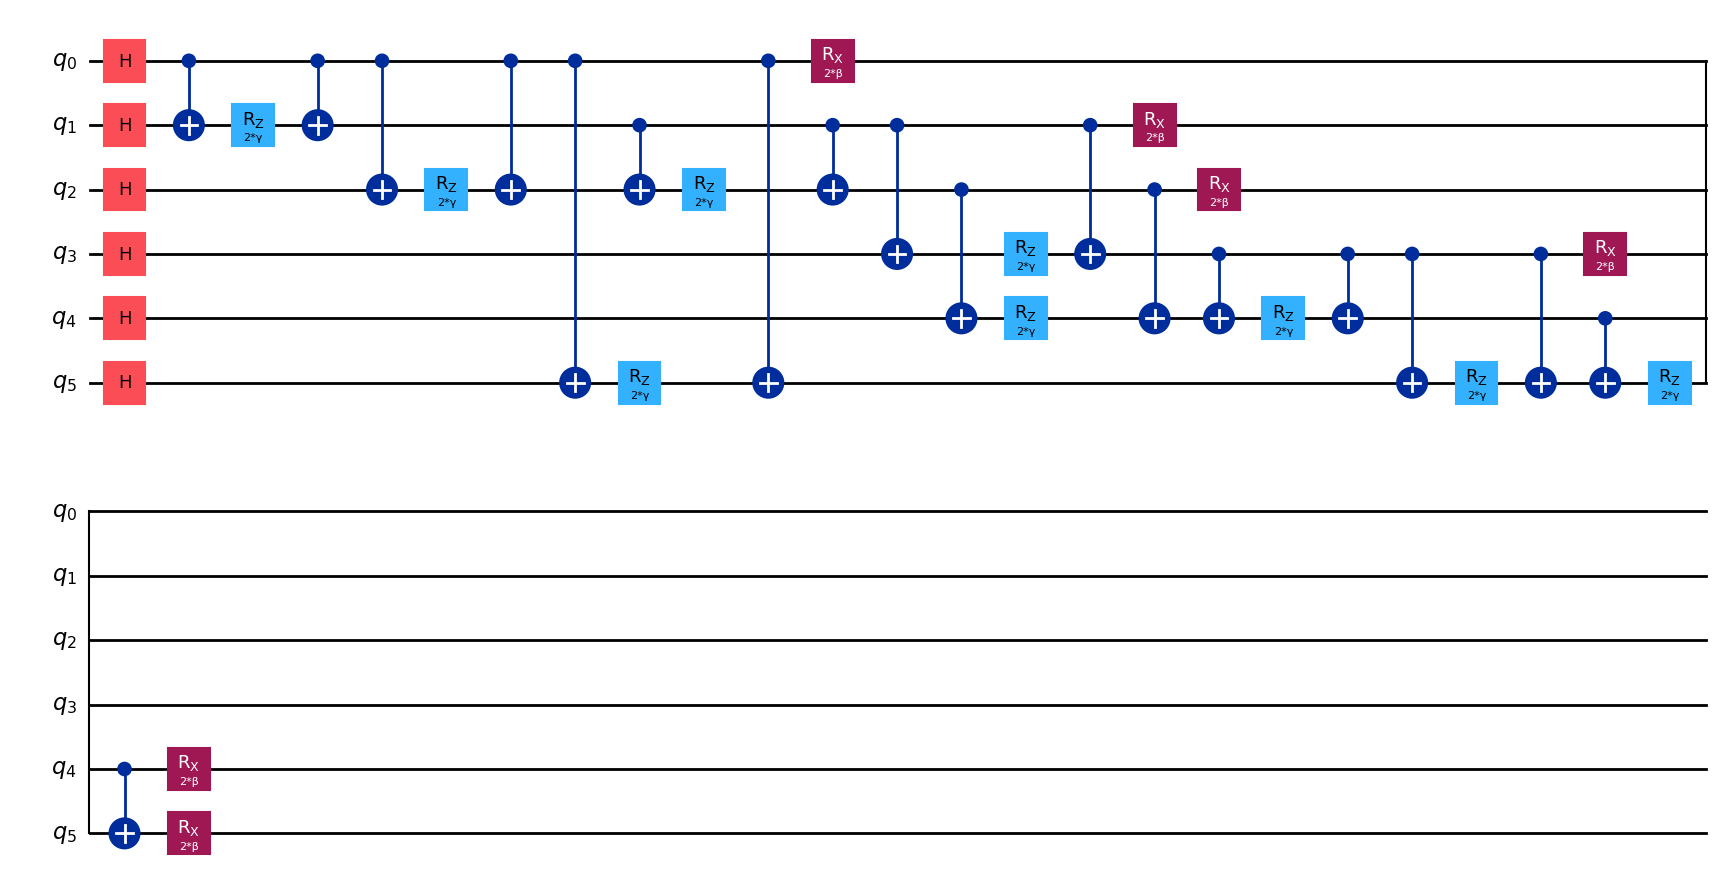

In [ ]:
# Circuito QAOA con una capa (p = 1)
circuito_qaoa = QuantumCircuit(num_nodos)

# Estado inicial uniforme
circuito_qaoa.h(range(num_nodos))

# Operador de costo
for nodo_i, nodo_j in aristas:

    circuito_qaoa.cx(nodo_i, nodo_j)
    circuito_qaoa.rz(2 * gamma, nodo_j)
    circuito_qaoa.cx(nodo_i, nodo_j)

# Operador mezclador
for qubit in range(num_nodos):
    circuito_qaoa.rx(2 * beta, qubit)

# Visualizamos el circuito
circuito_qaoa.draw("mpl")

# **6. Implementación y resultados**

Una vez construido el **circuito QAOA**, procedo a evaluar su **desempeño** sobre el problema **MaxCut** considerado. Para ello, primero obtendré la **solución óptima** mediante una **búsqueda clásica exhaustiva** y posteriormente implementaré **QAOA** para **aproximar dicha solución**. Finalmente, compararé ambos resultados para analizar la **capacidad del algoritmo** para encontrar el **corte máximo del grafo**.

## **6.1. Solución clásica mediante búsqueda exhaustiva**

Para la **instancia de MaxCut** considerada en este proyecto, definida por las **aristas**:

$$ E = \{(0,1), (0,2), (0,5), (1,2), (1,3), (2,4), (3,4), (3,5), (4,5)\} $$

es posible evaluar **exhaustivamente** todas las **particiones de los seis nodos**. Como existen:

$$ 2^6 = 64 $$

**configuraciones binarias posibles**, se puede determinar exactamente la **solución óptima de MaxCut**, la cual servirá como **referencia** para comparar posteriormente los **resultados obtenidos mediante QAOA**.

In [ ]:
# Importamos product para generar todas las combinaciones binarias
from itertools import product

# Inicializamos la mejor solución encontrada
mejor_valor = -1
mejor_cadena_bits = None

# Contador de iteraciones
iteracion = 0

# Recorremos las 2^n particiones posibles
for cadena_bits in product([0, 1], repeat=num_nodos):

    iteracion += 1

    # Calculamos el valor del corte
    valor = valor_maxcut(cadena_bits, aristas)

    print(
        f"Iteración {iteracion:2d}: "
        f"cadena_bits = {cadena_bits} | "
        f"valor = {valor}"
    )

    # Actualizamos la mejor solución encontrada
    if valor > mejor_valor:

        mejor_valor = valor
        mejor_cadena_bits = cadena_bits

        print(
            f"   Nueva mejor solución -> "
            f"{mejor_cadena_bits} "
            f"(valor = {mejor_valor})"
        )

# Mostramos la solución óptima
print("\nResultado final")
print("Mejor cadena de bits:", mejor_cadena_bits)
print("Valor óptimo de MaxCut:", mejor_valor)

Iteración  1: cadena_bits = (0, 0, 0, 0, 0, 0) | valor = 0
   Nueva mejor solución -> (0, 0, 0, 0, 0, 0) (valor = 0)
Iteración  2: cadena_bits = (0, 0, 0, 0, 0, 1) | valor = 3
   Nueva mejor solución -> (0, 0, 0, 0, 0, 1) (valor = 3)
Iteración  3: cadena_bits = (0, 0, 0, 0, 1, 0) | valor = 3
Iteración  4: cadena_bits = (0, 0, 0, 0, 1, 1) | valor = 4
   Nueva mejor solución -> (0, 0, 0, 0, 1, 1) (valor = 4)
Iteración  5: cadena_bits = (0, 0, 0, 1, 0, 0) | valor = 3
Iteración  6: cadena_bits = (0, 0, 0, 1, 0, 1) | valor = 4
Iteración  7: cadena_bits = (0, 0, 0, 1, 1, 0) | valor = 4
Iteración  8: cadena_bits = (0, 0, 0, 1, 1, 1) | valor = 3
Iteración  9: cadena_bits = (0, 0, 1, 0, 0, 0) | valor = 3
Iteración 10: cadena_bits = (0, 0, 1, 0, 0, 1) | valor = 6
   Nueva mejor solución -> (0, 0, 1, 0, 0, 1) (valor = 6)
Iteración 11: cadena_bits = (0, 0, 1, 0, 1, 0) | valor = 4
Iteración 12: cadena_bits = (0, 0, 1, 0, 1, 1) | valor = 5
Iteración 13: cadena_bits = (0, 0, 1, 1, 0, 0) | valor = 6
I

## **6.2. Implementación mediante QAOA**

Ya hemos construido el **circuito QAOA** en la sección anterior, ahora se procede a evaluar su **desempeño** sobre la instancia de **MaxCut** considerada. En esta sección **no se vuelve a construir el circuito desde cero**, sino que se utiliza el **circuito parametrizado** qc_qaoa, el cual depende de los **parámetros variacionales** $\gamma$ y $\beta$.

El **objetivo** es encontrar **valores adecuados** de estos parámetros para que el circuito produzca, con **alta probabilidad**, **bitstrings** asociados a **cortes grandes** del grafo.

In [ ]:
from qiskit_aer import AerSimulator
from scipy.optimize import minimize

Simulador:

In [ ]:
simulador = AerSimulator()

Para evaluar el **desempeño de QAOA**, se asignan **valores concretos** a los parámetros $\gamma$ y $\beta$ del circuito qc_qaoa. Después se realizan **mediciones** y se calcula el **valor esperado de MaxCut** a partir de los **bitstrings** obtenidos.

In [ ]:
# Evalúa el valor esperado de MaxCut para un conjunto de parámetros
def evaluar_qaoa(parametros, disparos=2048):

    valor_gamma, valor_beta = parametros

    # Asignamos valores numéricos a los parámetros del circuito
    circuito_parametrizado = circuito_qaoa.assign_parameters({
        gamma: valor_gamma,
        beta: valor_beta
    })

    # Copiamos el circuito para añadir mediciones
    circuito_medido = circuito_parametrizado.copy()
    circuito_medido.measure_all()

    # Ejecutamos la simulación
    resultado = simulador.run(
        circuito_medido,
        shots=disparos
    ).result()

    conteos = resultado.get_counts()

    valor_esperado = 0

    # Calculamos el valor esperado de MaxCut
    for bitstring, conteo in conteos.items():

        # Qiskit devuelve los bits en orden inverso
        cadena_bits = tuple(
            int(bit)
            for bit in bitstring[::-1]
        )

        valor = valor_maxcut(
            cadena_bits,
            aristas
        )

        probabilidad = conteo / disparos

        valor_esperado += probabilidad * valor

    return valor_esperado

Como el **optimizador clásico** **minimiza** funciones, se define como **función objetivo** el **negativo del valor esperado de MaxCut**. De esta manera, **minimizar** esta función equivale a **maximizar el corte esperado**.

Además, se guarda el **valor del costo** en cada **iteración** para poder **graficar** la **evolución de la optimización**.

In [ ]:
# Almacena la evolución del valor esperado durante la optimización
historial_costo = []

# Función objetivo para el optimizador clásico
def funcion_objetivo(parametros):

    valor_esperado = evaluar_qaoa(parametros)

    historial_costo.append(valor_esperado)

    # Se minimiza el negativo para maximizar MaxCut
    return -valor_esperado

Ahora se **optimizan** los **parámetros variacionales** $\gamma$ y $\beta$. Para ello se utiliza el método **COBYLA**, que es adecuado para problemas variacionales porque **no requiere calcular derivadas**.

In [ ]:
# Valores iniciales para los parámetros variacionales
parametros_iniciales = np.array([0.5, 0.5])

# Optimización clásica de los parámetros de QAOA
resultado_optimizacion = minimize(
    funcion_objetivo,
    parametros_iniciales,
    method="COBYLA",
    options={"maxiter": 80}
)

# Parámetros óptimos encontrados
gamma_optimo, beta_optimo = resultado_optimizacion.x

print("Parámetros óptimos encontrados")
print("gamma =", gamma_optimo)
print("beta  =", beta_optimo)
print(
    "Valor esperado máximo aproximado:",
    -resultado_optimizacion.fun
)

Parámetros óptimos encontrados
gamma = 1.313610684401922
beta  = 1.2146142017046533
Valor esperado máximo aproximado: 5.9775390625


La siguiente gráfica muestra la evolución del valor esperado de MaxCut durante la optimización.

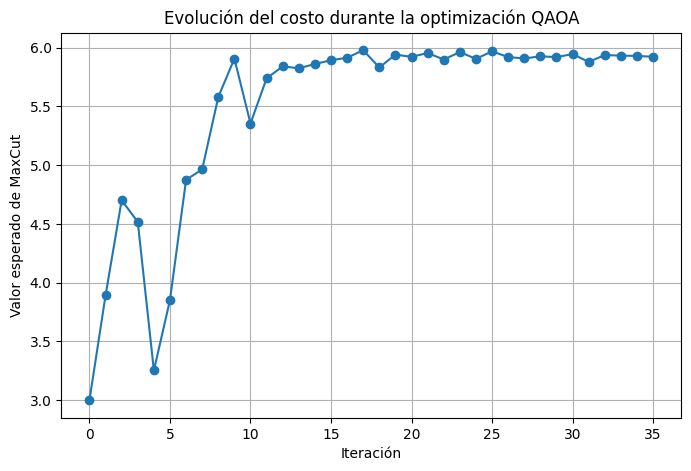

In [ ]:
# Evolución del valor esperado durante la optimización
plt.figure(figsize=(8, 5))

plt.plot(historial_costo, marker="o")

plt.xlabel("Iteración")
plt.ylabel("Valor esperado de MaxCut")
plt.title("Evolución del costo durante la optimización QAOA")

plt.grid(True)
plt.show()

**Observación:** El valor esperado converge hacia un valor cercano a 6, lo que indica que el proceso de optimización está encontrando parámetros que favorecen particiones con un número elevado de aristas cortadas.

Una vez encontrados los **parámetros óptimos**, se ejecuta nuevamente el **circuito QAOA** con un **mayor número de mediciones**. Esto permite **estimar con más claridad** la **distribución de probabilidades** de los **bitstrings** producidos por el algoritmo.

In [ ]:
# Asignamos los parámetros óptimos al circuito QAOA
circuito_optimo = circuito_qaoa.assign_parameters({
    gamma: gamma_optimo,
    beta: beta_optimo
})

# Añadimos mediciones al circuito
circuito_optimo_medido = circuito_optimo.copy()
circuito_optimo_medido.measure_all()

# Número de ejecuciones del circuito
disparos = 8192

# Ejecutamos la simulación
resultado_final = simulador.run(
    circuito_optimo_medido,
    shots=disparos
).result()

# Obtenemos los conteos de cada bitstring medido
conteos_finales = resultado_final.get_counts()

A continuación se **calculan** las **probabilidades** asociadas a cada **bitstring** medido y se **ordenan** de **mayor a menor probabilidad**.

In [ ]:
# Calculamos la probabilidad asociada a cada bitstring medido
probabilidades = {
    bitstring: conteo / disparos
    for bitstring, conteo in conteos_finales.items()
}

# Ordenamos las probabilidades de mayor a menor
probabilidades_ordenadas = sorted(
    probabilidades.items(),
    key=lambda elemento: elemento[1],
    reverse=True
)

Se **muestran** los **bitstrings más probables** en orden, obtenidos por **QAOA**, junto con su **probabilidad** y el **valor de MaxCut** asociado.

In [ ]:
print("Bitstrings más probables obtenidos por QAOA:\n")

for bitstring, probabilidad in probabilidades_ordenadas:

    cadena_bits = tuple(
        int(bit)
        for bit in bitstring[::-1]
    )

    valor = valor_maxcut(
        cadena_bits,
        aristas
    )

    print(
        f"Bitstring medido = {bitstring} | "
        f"Bits interpretados = {cadena_bits} | "
        f"Probabilidad = {probabilidad:.4f} | "
        f"MaxCut = {valor}"
    )

Bitstrings más probables obtenidos por QAOA:

Bitstring medido = 010011 | Bits interpretados = (1, 1, 0, 0, 1, 0) | Probabilidad = 0.0677 | MaxCut = 7
Bitstring medido = 110010 | Bits interpretados = (0, 1, 0, 0, 1, 1) | Probabilidad = 0.0676 | MaxCut = 7
Bitstring medido = 101100 | Bits interpretados = (0, 0, 1, 1, 0, 1) | Probabilidad = 0.0668 | MaxCut = 7
Bitstring medido = 011001 | Bits interpretados = (1, 0, 0, 1, 1, 0) | Probabilidad = 0.0665 | MaxCut = 7
Bitstring medido = 001101 | Bits interpretados = (1, 0, 1, 1, 0, 0) | Probabilidad = 0.0663 | MaxCut = 7
Bitstring medido = 100110 | Bits interpretados = (0, 1, 1, 0, 0, 1) | Probabilidad = 0.0615 | MaxCut = 7
Bitstring medido = 010010 | Bits interpretados = (0, 1, 0, 0, 1, 0) | Probabilidad = 0.0253 | MaxCut = 6
Bitstring medido = 110110 | Bits interpretados = (0, 1, 1, 0, 1, 1) | Probabilidad = 0.0245 | MaxCut = 6
Bitstring medido = 110011 | Bits interpretados = (1, 1, 0, 0, 1, 1) | Probabilidad = 0.0245 | MaxCut = 6
Bitstring

También se **grafica** la **distribución de probabilidad** de los **bitstrings más frecuentes**.

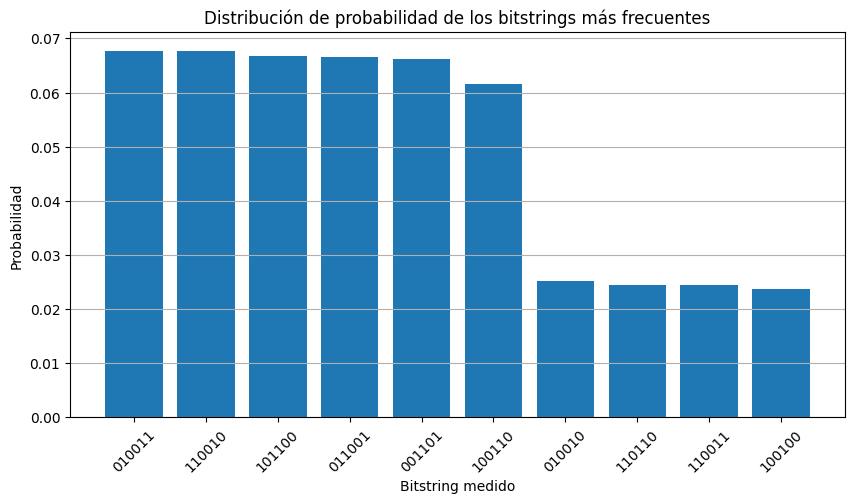

In [ ]:
# Seleccionamos los 10 bitstrings más probables
bitstrings_principales = [
    elemento[0]
    for elemento in probabilidades_ordenadas[:10]
]

probabilidades_principales = [
    elemento[1]
    for elemento in probabilidades_ordenadas[:10]
]

# Graficamos las probabilidades
plt.figure(figsize=(10, 5))

plt.bar(
    bitstrings_principales,
    probabilidades_principales
)

plt.xlabel("Bitstring medido")
plt.ylabel("Probabilidad")
plt.title(
    "Distribución de probabilidad de los bitstrings más frecuentes"
)

plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

## **6.3. Comparación con la solución clásica**

Una vez obtenida la **distribución de probabilidad** generada por **QAOA**, se toma el **bitstring más probable** como la **solución propuesta por el algoritmo**. Posteriormente, este **resultado** se **compara** con la **solución óptima** obtenida mediante **búsqueda exhaustiva**.

In [ ]:
# Bitstring con mayor probabilidad de aparición
bitstring_mas_probable = probabilidades_ordenadas[0][0]

# Conversión al formato utilizado en MaxCut
solucion_qaoa = tuple(
    int(bit)
    for bit in bitstring_mas_probable[::-1]
)

# Valor del corte asociado
valor_qaoa = valor_maxcut(
    solucion_qaoa,
    aristas
)

print("Resultado propuesto por QAOA")
print("Bitstring más probable:", bitstring_mas_probable)
print("Solución interpretada:", solucion_qaoa)
print("Valor de MaxCut:", valor_qaoa)

print("\nComparación con la búsqueda clásica")
print("Mejor solución clásica:", mejor_cadena_bits)
print("Valor óptimo clásico:", mejor_valor)

Resultado propuesto por QAOA
Bitstring más probable: 010011
Solución interpretada: (1, 1, 0, 0, 1, 0)
Valor de MaxCut: 7

Comparación con la búsqueda clásica
Mejor solución clásica: (0, 0, 1, 1, 0, 1)
Valor óptimo clásico: 7


En esta **instancia pequeña**, la **búsqueda exhaustiva** permite conocer exactamente la **solución óptima**. Sin embargo, el **interés de QAOA** radica en que puede aplicarse a **instancias más grandes** donde evaluar las $2^n$ configuraciones posibles **deja de ser factible**.

# **7. Comparación de optimizadores clásicos para QAOA**

En esta sección se comparan tres **optimizadores** ampliamente utilizados:

- **COBYLA** (Constrained Optimization By Linear Approximation).
- **Nelder-Mead**.
- **Powell**.

Todos ellos utilizan el mismo **punto inicial**:

$$ (\gamma, \beta) = (0.5, 0.5) $$

y el mismo **límite máximo de iteraciones**.

Ejecución de distintos optimizadores:

In [ ]:
# Optimizadores clásicos que se compararán
optimizadores = [
    "COBYLA",
    "Nelder-Mead",
    "Powell"
]

# Diccionario para almacenar los resultados
resultados_optimizadores = {}

# Recorremos cada optimizador
for optimizador in optimizadores:

    # Historial local de la función objetivo
    historial_local = []

    # Función objetivo utilizada por el optimizador
    def funcion_objetivo_local(parametros):

        valor_esperado = evaluar_qaoa(parametros)

        historial_local.append(valor_esperado)

        return -valor_esperado

    # Ejecutamos la optimización
    resultado_optimizacion = minimize(
        funcion_objetivo_local,
        parametros_iniciales,
        method=optimizador,
        options={"maxiter": 80}
    )

    # Guardamos resultados e historial
    resultados_optimizadores[optimizador] = {
        "resultado": resultado_optimizacion,
        "historial": historial_local
    }

Comparación de parámetros óptimos:

In [ ]:
# Mostramos los parámetros obtenidos por cada optimizador
print("Comparación de optimizadores\n")

for optimizador, datos in resultados_optimizadores.items():

    resultado = datos["resultado"]

    gamma_optimo = resultado.x[0]
    beta_optimo = resultado.x[1]

    valor_final = -resultado.fun

    print(f"Optimizador: {optimizador}")
    print(f"  gamma = {gamma_optimo:.4f}")
    print(f"  beta  = {beta_optimo:.4f}")
    print(f"  Valor esperado = {valor_final:.4f}")
    print()

Comparación de optimizadores

Optimizador: COBYLA
  gamma = 1.3190
  beta  = 1.2078
  Valor esperado = 5.9707

Optimizador: Nelder-Mead
  gamma = 1.2763
  beta  = -0.3903
  Valor esperado = 5.9790

Optimizador: Powell
  gamma = 2.8496
  beta  = 0.3668
  Valor esperado = 5.9570



Evolución de la optimización:

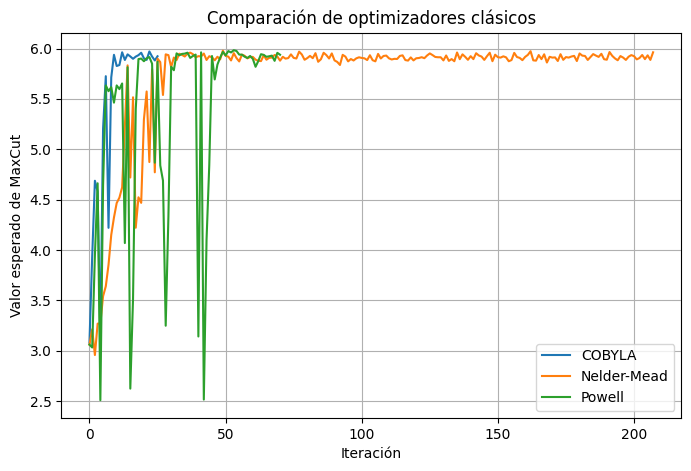

In [ ]:
# Creamos la figura
plt.figure(figsize=(8, 5))

# Graficamos la evolución de cada optimizador
for optimizador, datos in resultados_optimizadores.items():

    plt.plot(
        datos["historial"],
        label=optimizador
    )

# Configuración de la gráfica
plt.xlabel("Iteración")
plt.ylabel("Valor esperado de MaxCut")
plt.title("Comparación de optimizadores clásicos")

plt.legend()
plt.grid(True)

# Mostramos la figura
plt.show()

Tabla comparativa:

In [ ]:
# Encabezado de la tabla
print(
    f"{'Método':<15}"
    f"{'Valor esperado':<20}"
    f"{'Gamma':<12}"
    f"{'Beta':<12}"
)

print("-" * 60)

# Mostramos los resultados resumidos
for optimizador, datos in resultados_optimizadores.items():

    resultado = datos["resultado"]

    print(
        f"{optimizador:<15}"
        f"{-resultado.fun:<20.4f}"
        f"{resultado.x[0]:<12.4f}"
        f"{resultado.x[1]:<12.4f}"
    )

Método         Valor esperado      Gamma       Beta        
------------------------------------------------------------
COBYLA         5.9707              1.3190      1.2078      
Nelder-Mead    5.9790              1.2763      -0.3903     
Powell         5.9570              2.8496      0.3668      


Simulación final de cada optimizador:

In [ ]:
# Diccionario para guardar la mejor solución medida por cada optimizador
soluciones_optimizadores = {}

# Número de disparos para la simulación final
disparos_finales = 8192

# Recorremos cada optimizador
for optimizador, datos in resultados_optimizadores.items():

    # Extraemos el resultado de la optimización
    resultado_optimizador = datos["resultado"]

    # Parámetros óptimos encontrados por ese optimizador
    gamma_optimo = resultado_optimizador.x[0]
    beta_optimo = resultado_optimizador.x[1]

    # Asignamos los parámetros óptimos al circuito QAOA
    circuito_optimo = circuito_qaoa.assign_parameters({
        gamma: gamma_optimo,
        beta: beta_optimo
    })

    # Copiamos el circuito y añadimos mediciones
    circuito_medido = circuito_optimo.copy()
    circuito_medido.measure_all()

    # Ejecutamos la simulación final
    resultado_simulacion = simulador.run(
        circuito_medido,
        shots=disparos_finales
    ).result()

    # Obtenemos los conteos
    conteos = resultado_simulacion.get_counts()

    # Convertimos conteos a probabilidades
    probabilidades = {
        bitstring: conteo / disparos_finales
        for bitstring, conteo in conteos.items()
    }

    # Ordenamos las probabilidades
    probabilidades_ordenadas = sorted(
        probabilidades.items(),
        key=lambda elemento: elemento[1],
        reverse=True
    )

    # Tomamos el bitstring más probable
    bitstring_mas_probable = probabilidades_ordenadas[0][0]

    # Interpretamos el bitstring en el orden usado por MaxCut
    solucion_qaoa = tuple(
        int(bit)
        for bit in bitstring_mas_probable[::-1]
    )

    # Calculamos su valor de MaxCut
    valor_qaoa = valor_maxcut(
        solucion_qaoa,
        aristas
    )

    # Guardamos los resultados
    soluciones_optimizadores[optimizador] = {
        "bitstring": bitstring_mas_probable,
        "solucion": solucion_qaoa,
        "probabilidad": probabilidades_ordenadas[0][1],
        "valor_maxcut": valor_qaoa,
        "probabilidades": probabilidades_ordenadas
    }

In [ ]:
# Mostramos la solución más probable obtenida con cada optimizador
print("Comparación de soluciones medidas\n")

for optimizador, datos in soluciones_optimizadores.items():

    print(f"Optimizador: {optimizador}")
    print(f"  Bitstring más probable: {datos['bitstring']}")
    print(f"  Solución interpretada: {datos['solucion']}")
    print(f"  Probabilidad: {datos['probabilidad']:.4f}")
    print(f"  Valor MaxCut: {datos['valor_maxcut']}")
    print()

Comparación de soluciones medidas

Optimizador: COBYLA
  Bitstring más probable: 110010
  Solución interpretada: (0, 1, 0, 0, 1, 1)
  Probabilidad: 0.0670
  Valor MaxCut: 7

Optimizador: Nelder-Mead
  Bitstring más probable: 101100
  Solución interpretada: (0, 0, 1, 1, 0, 1)
  Probabilidad: 0.0693
  Valor MaxCut: 7

Optimizador: Powell
  Bitstring más probable: 010011
  Solución interpretada: (1, 1, 0, 0, 1, 0)
  Probabilidad: 0.0715
  Valor MaxCut: 7



# **Referencias:**

- Farhi, E., Goldstone, J., & Gutmann, S. (2014). A Quantum Approximate
Optimization Algorithm. arXiv. https://arxiv.org/abs/1411.4028

- Quantum approximate optimization algorithm | IBM Quantum Documentation. (2017). IBM Quantum Documentation. https://quantum.cloud.ibm.com/docs/en/tutorials/quantum-approximate-optimization-algorithm

- QAOA for Max-Cut | Qiskit Optimization Tutorials. (2024). Qiskit Documentation. https://qiskit-community.github.io/qiskit-optimization/tutorials/06_examples_max_cut_and_tsp.html

- MaxCut. (2024). Qiskit Optimization Documentation. https://qiskit-community.github.io/qiskit-optimization/stubs/qiskit_optimization.applications.Maxcut.html

- Hadfield, S., Wang, Z., O'Gorman, B., Rieffel, E., Venturelli, D., & Biswas, R. (2019). From the Quantum Approximate Optimization Algorithm to a Quantum Alternating Operator Ansatz. Algorithms, 12(2), 34. https://doi.org/10.3390/a12020034

- Lucas, A. (2014). Ising formulations of many NP problems. Frontiers in Physics, 2, 5. https://doi.org/10.3389/fphy.2014.00005

- Glover, F., Kochenberger, G., & Du, Y. (2019). A Tutorial on Formulating and Using QUBO Models. arXiv. https://arxiv.org/abs/1811.11538
